### Group members: Thanh Nguyen, Madison Yin, Leena Koussa, Rose Alvarado

## Setup:
Setting up our mutual funds. Note that we have 4 mutual funds [A,B,C,D] with the following distributions/returns:

- A: $Unif[-40\%, 60\%]$
- B: $Unif[-10\%, 24\%]$
- C: $Normal(7\%, (2\%)^2)$
- D: $Unif[5\%, 7\%]$

We will also start with `$1,000,000`. Our goal will be to determine the best investment strategy.

The code below contains several functions about portfolios, which are an array of 4 numbers indicating the amount invested in each stock respectively.

In [511]:
# %pip install numpy matplotlib scipy
# uncomment during first run to install dependencies

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

NUM_SIMS = 1000000
SEED = 42 # the Answer to the Ultimate Question of Life, the Universe, and Everything
SHORT_TERM_YEARS = 3
LONG_TERM_YEARS = 10

SHORT_TERM_SCORES = []
LONG_TERM_SCORES = []

np.random.seed(SEED)

def setup_portfolios(starting_portfolio: list[float], num_portfolios: int) -> list[list[float]]:
        return [starting_portfolio.copy() for _ in range(num_portfolios)]

# Returns an array of the values of a specific stock type across all portfolios
def filter_portfolios(portfolios: list[list[float]], stock_type: str) -> np.ndarray:
        
        np_arr = np.array(portfolios)

        match stock_type:
                case 'A':
                        return np_arr[:, 0]
                case 'B':
                        return np_arr[:, 1]
                case 'C':
                        return np_arr[:, 2]
                case 'D':
                        return np_arr[:, 3]
                case _:
                        raise ValueError(f"Invalid stock type: {stock_type}")

# Returns an array containing the total value of each portfolio
def get_portfolio_totals(portfolios: list[list[float]]) -> np.ndarray:
        return np.sum(portfolios, axis=1)

# Returns the number of values that have a total value greater than the threshold
def percent_of_values_above(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values > threshold) / len(values) * 100

# Returns the number of values that have a total value less than or equal to the threshold
def percent_of_values_below(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values <= threshold) / len(values) * 100

def percent_of_return(end, start) -> float:
        return (end - start) / start * 100

def percent_of_outliers(values: np.ndarray) -> float:
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr = q75 - q25
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr
        outliers = np.sum((values < lower_bound) | (values > upper_bound))
        return outliers / len(values) * 100

def calculate_CE(values: np.ndarray, lam: int | float) -> float:
       W_0 = 1_000_000
       values = np.asarray(winsorize(values, limits=[0.01, 0.01])) # winsorize the values to limit the influence of outliers
       ratio = values / W_0  #wi/w_0

       #risk neutral case
       if(lam == 0): 
               return float(np.mean(ratio))
       
       e_term = np.exp(-lam * ratio) # e^(-lambda * ratio)
       mean_E = np.mean(e_term) # E[e_term]
       
       return float(-(1/lam) * np.log(mean_E))

def get_scores(values: np.ndarray) -> list[float]:
        risk_averse_score = calculate_CE(values, 1)
        risk_neutral_score = calculate_CE(values, 0)
        risk_seeking_score =  calculate_CE(values, -1)

        return [risk_averse_score, risk_neutral_score, risk_seeking_score]

def print_stats(values: np.ndarray, header: str = "Stats:", footer: str = ""):
        mean = np.mean(values)
        median = np.median(values)
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr_value = q75 - q25
        outlier_percentage = percent_of_outliers(values)
        std = np.std(values)
        scores = get_scores(values)

        print(
                f"{header}\n"
                f"Mean: ${mean:,.2f}\n"
                f"Mean return: {percent_of_return(mean, 1000000):.2f}%\n"
                f"Standard Deviation: ${std:,.2f}\n\n"
                
                f"Median: ${median:,.2f}\n"
                f"Median return: {percent_of_return(median, 1000000):.2f}%\n"
                f"Min: ${np.min(values):,.2f}\n"
                f"Max: ${np.max(values):,.2f}\n"
                f"Q1 (25th percentile): ${q25:,.2f}\n"
                f"Q3 (75th percentile): ${q75:,.2f}\n"
                f"IQR: ${iqr_value:,.2f}\n\n"

                f"Percentage of failed portfolios: {percent_of_values_below(values, 1000000):.2f}%\n"
                f"Percentage of outliers: {outlier_percentage:.2f}%\n\n"

                f"Risk-averse score: {scores[0]:,.5f}\n"
                f"Risk-neutral score: {scores[1]:,.5f}\n"
                f"Risk-seeking score: {scores[2]:,.5f}\n"
                f"{footer}"
        )

# Simulates one year of returns for a single portfolio
def simulate_once(portfolio: list[float]):
        change_a = np.random.uniform(-0.4, 0.6)
        change_b = np.random.uniform(-0.1, 0.24)
        change_c = np.random.normal(0.07, 0.02)
        change_d = np.random.uniform(0.05, 0.07)

        portfolio[0] *= (1 + change_a)
        portfolio[1] *= (1 + change_b)
        portfolio[2] *= (1 + change_c)
        portfolio[3] *= (1 + change_d)

# Simulates multiple years of returns for a list of portfolios
def simulate_multiple(portfolios: list[list[float]], num_years: int):
        for _ in range(num_years):
                for portfolio in portfolios:
                        simulate_once(portfolio)

### Question 1:

##### What is the expected return if you invest option A for 3 years? 

In [512]:
starting_portfolio = [1000000.0, 1000000.0, 1000000.0, 1000000.0]  # do all 4 stock simulations at once
portfolios = setup_portfolios(starting_portfolio, NUM_SIMS)

simulate_multiple(portfolios, SHORT_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
SHORT_TERM_SCORES.append(get_scores(fund_A_values))
print_stats(fund_A_values, header="+ Fund A stats after 3 years:")

+ Fund A stats after 3 years:
Mean: $1,330,691.95
Mean return: 33.07%
Standard Deviation: $626,165.71

Median: $1,212,808.11
Median return: 21.28%
Min: $217,281.07
Max: $4,063,066.12
Q1 (25th percentile): $857,281.04
Q3 (75th percentile): $1,683,116.41
IQR: $825,835.37

Percentage of failed portfolios: 35.30%
Percentage of outliers: 2.04%

Risk-averse score: 1.16795
Risk-neutral score: 1.32885
Risk-seeking score: 1.55170



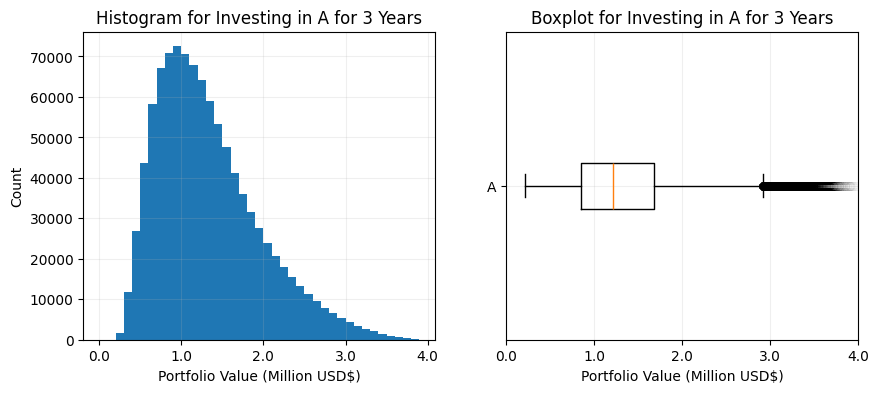

In [513]:
# plots for fund A

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 4000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax2.set_yticklabels(["A"])
ax2.set_xlim(0, 4000001)

plt.show()

##### What is the probability that your profit is more than 25%? 

$ P(T > 1,250,000) =  ? $

In [514]:
print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_A_values, 1250000):.2f}%")

Percentage of portfolios with over $1,250,000 after 3 years: 47.60%


##### What is the probability that you lose 25% of your money?

$ P(T \le 750,000) = ?$

In [515]:
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_A_values, 750000):.2f}%")

Percentage of portfolios with $750,000 or less after 3 years: 17.54%


### Question 2:
##### What are your answers if you invest in fund B or C? And what is your recommendation for the best option?

In [516]:
# calculations for fund B
fund_B_values = filter_portfolios(portfolios, "B")
SHORT_TERM_SCORES.append(get_scores(fund_B_values))
print_stats(fund_B_values, header="+ Fund B stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_B_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_B_values, 750000):.2f}%")

+ Fund B stats after 3 years:
Mean: $1,225,073.54
Mean return: 22.51%
Standard Deviation: $195,360.46

Median: $1,212,110.64
Median return: 21.21%
Min: $734,386.48
Max: $1,901,784.96
Q1 (25th percentile): $1,081,302.70
Q3 (75th percentile): $1,354,725.79
IQR: $273,423.08

Percentage of failed portfolios: 12.36%
Percentage of outliers: 0.35%

Risk-averse score: 1.20653
Risk-neutral score: 1.22486
Risk-seeking score: 1.24390

Percentage of portfolios with over $1,250,000 after 3 years: 42.74%
Percentage of portfolios with $750,000 or less after 3 years: 0.01%


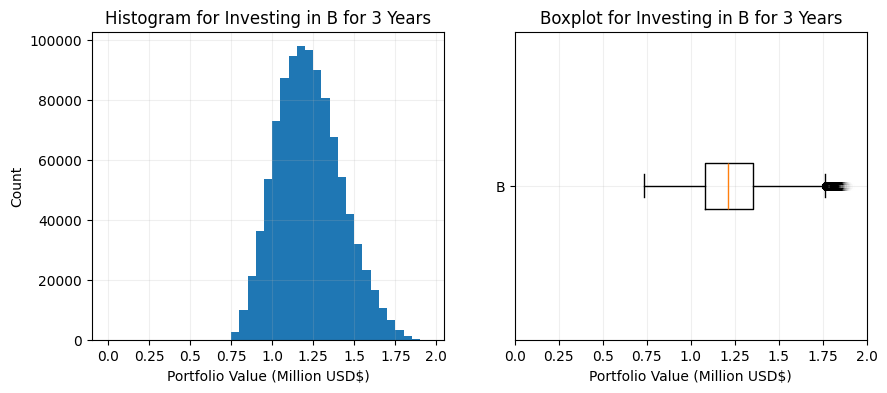

In [517]:
# plots for fund B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 2000000, 50000)) # each bin will be 50k
ax1.set_xticks(ticks=range(0,2000000,200000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax2.set_yticklabels(["B"])
ax2.set_xlim(0, 2000001)

plt.show()


In [518]:
# calculations for fund C
fund_C_values = filter_portfolios(portfolios, "C")
SHORT_TERM_SCORES.append(get_scores(fund_C_values))
print_stats(fund_C_values, header="+ Fund C stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_C_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_C_values, 750000):.2f}%")


+ Fund C stats after 3 years:
Mean: $1,225,073.60
Mean return: 22.51%
Standard Deviation: $39,694.86

Median: $1,224,607.77
Median return: 22.46%
Min: $1,043,825.92
Max: $1,415,905.21
Q1 (25th percentile): $1,198,049.56
Q3 (75th percentile): $1,251,576.73
IQR: $53,527.17

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.71%

Risk-averse score: 1.22430
Risk-neutral score: 1.22506
Risk-seeking score: 1.22582

Percentage of portfolios with over $1,250,000 after 3 years: 26.25%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


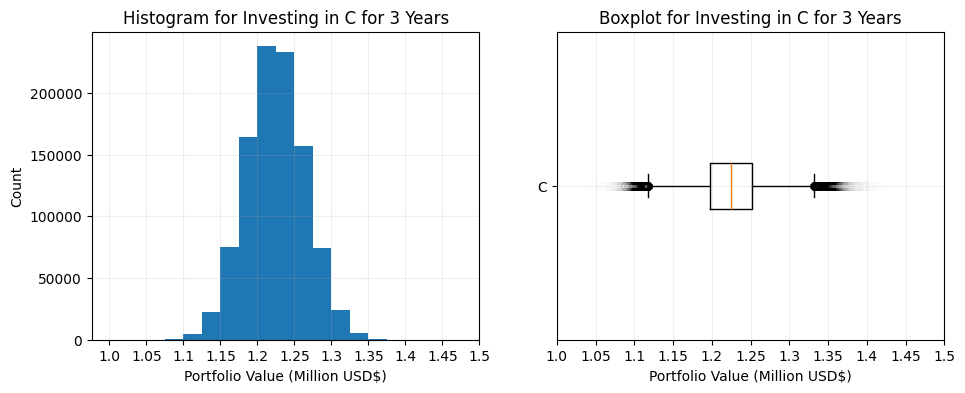

In [519]:
# plots for fund C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

histogram = ax1.hist(fund_C_values, bins=range(1000000, 1500000, 25000)) # each bin will be 25k
ax1.set_xticks(ticks=range(1000000,1500000,50000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax2.set_yticklabels(["C"])
ax2.set_xlim(1000000, 1500001)

plt.show()


##### What about investing everything in fund D for 3 years?

In [520]:
# calculations for fund D
fund_D_values = filter_portfolios(portfolios, "D")
SHORT_TERM_SCORES.append(get_scores(fund_D_values))
print_stats(fund_D_values, header="+ Fund D stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_D_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_D_values, 750000):.2f}%")

+ Fund D stats after 3 years:
Mean: $1,191,018.67
Mean return: 19.10%
Standard Deviation: $11,240.38

Median: $1,190,973.60
Median return: 19.10%
Min: $1,157,839.65
Max: $1,224,668.68
Q1 (25th percentile): $1,183,059.13
Q3 (75th percentile): $1,198,926.38
IQR: $15,867.25

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.02%

Risk-averse score: 1.19096
Risk-neutral score: 1.19102
Risk-seeking score: 1.19108

Percentage of portfolios with over $1,250,000 after 3 years: 0.00%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


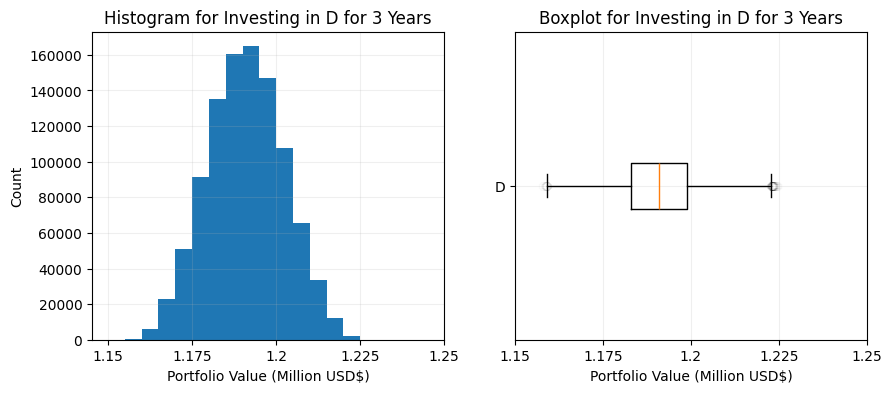

In [521]:
# plots for fund D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1150000, 1250000, 5000)) # each bin will be 5k
ax1.set_xticks(ticks=range(1150000,1250001,25000), labels=list(np.round((np.arange(1.15, 1.251, 0.025)), decimals=3)))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(ticks=range(1150000,1250001,25000), labels=list(np.round((np.arange(1.15, 1.251, 0.025)), decimals=3)))
ax2.set_yticklabels(["D"])
ax2.set_xlim(1150000, 1250001)

plt.show()


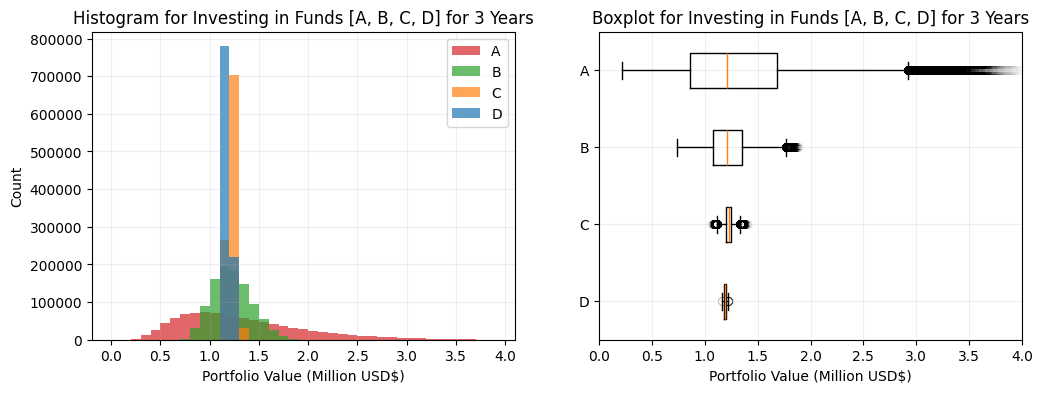

In [522]:
# combining outcomes for funds A, B, C, D into into a single plot for simplicity

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

stacked_hist = ax1.hist([fund_D_values, fund_C_values, fund_B_values, fund_A_values], histtype="stepfilled", bins=range(0, 4000000, 100000), label=["D", "C", "B", "A"], alpha=0.7)
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in Funds [A, B, C, D] for 3 Years")
ax1.legend()
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax1.set_ylabel("Count")

multi_boxplot = ax2.boxplot([fund_D_values, fund_C_values, fund_B_values, fund_A_values], label=["D", "C", "B", "A"], vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in Funds [A, B, C, D] for 3 Years")
ax2.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax2.set_yticks(ticks=[1,2,3,4], labels=["D", "C", "B", "A"])
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(0, 4000001)

plt.show()

### Question 3:
##### How will your answer/recommendation change if you are planning for 10 years, instead of 3 years?

In [523]:
portfolios = setup_portfolios([1000000.0, 1000000.0, 1000000.0, 1000000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
fund_B_values = filter_portfolios(portfolios, "B")
fund_C_values = filter_portfolios(portfolios, "C")
fund_D_values = filter_portfolios(portfolios, "D")

LONG_TERM_SCORES.append(get_scores(fund_A_values))
LONG_TERM_SCORES.append(get_scores(fund_B_values))
LONG_TERM_SCORES.append(get_scores(fund_C_values))
LONG_TERM_SCORES.append(get_scores(fund_D_values))

Here are some statistics and graphs for each fund: 

+ Fund A stats after 10 years:
Mean: $2,593,663.69
Mean return: 159.37%
Standard Deviation: $2,519,734.23

Median: $1,825,567.24
Median return: 82.56%
Min: $33,377.01
Max: $55,092,328.22
Q1 (25th percentile): $997,959.87
Q3 (75th percentile): $3,287,488.08
IQR: $2,289,528.21

Percentage of failed portfolios: 25.08%
Percentage of outliers: 6.30%

Risk-averse score: 1.48632
Risk-neutral score: 2.55707
Risk-seeking score: 8.20310



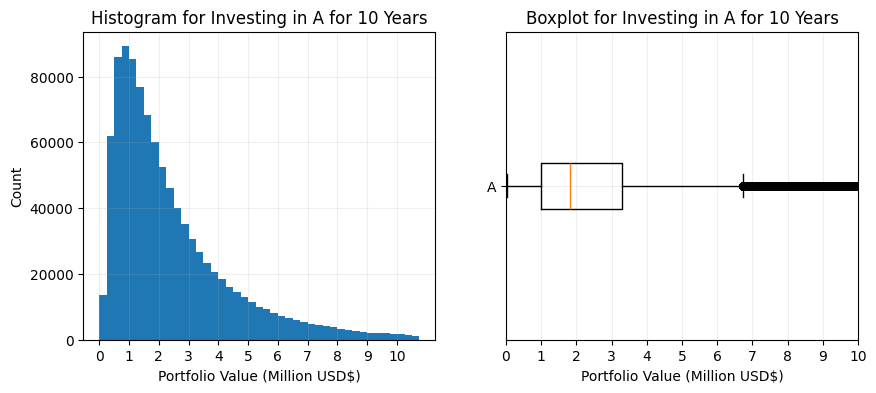

In [524]:
# fund A
print_stats(fund_A_values, "+ Fund A stats after 10 years:")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 11000000, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,11000000, 1000000), list(range(0,11))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 11000000, 1000000), list(range(0,11))) # type: ignore
ax2.set_yticks([1], ["A"])
ax2.set_xlim(0,10000000)

plt.show()

+ Fund B stats after 10 years:
Mean: $1,967,149.87
Mean return: 96.71%
Standard Deviation: $116,297.44

Median: $1,963,927.67
Median return: 96.39%
Min: $1,452,979.93
Max: $2,675,943.55
Q1 (25th percentile): $1,887,048.16
Q3 (75th percentile): $2,043,853.40
IQR: $156,805.24

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.75%

Risk-averse score: 1.96056
Risk-neutral score: 1.96704
Risk-seeking score: 1.97359



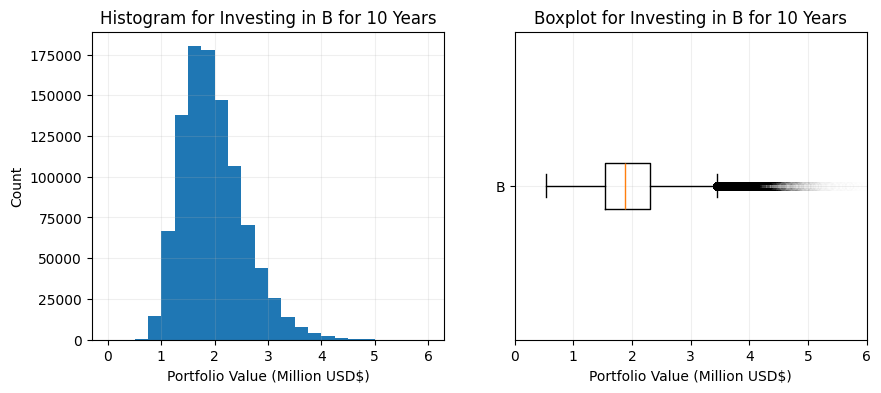

In [525]:
# fund B
print_stats(fund_C_values, "+ Fund B stats after 10 years:")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 6000001, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,6000001, 1000000), list(range(0,7))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 6000001, 1000000), list(range(0,7))) # type: ignore
ax2.set_yticks([1], ["B"])
ax2.set_xlim(0,6000001) 

plt.show()

+ Fund C stats after 10 years:
Mean: $1,967,149.87
Mean return: 96.71%
Standard Deviation: $116,297.44

Median: $1,963,927.67
Median return: 96.39%
Min: $1,452,979.93
Max: $2,675,943.55
Q1 (25th percentile): $1,887,048.16
Q3 (75th percentile): $2,043,853.40
IQR: $156,805.24

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.75%

Risk-averse score: 1.96056
Risk-neutral score: 1.96704
Risk-seeking score: 1.97359



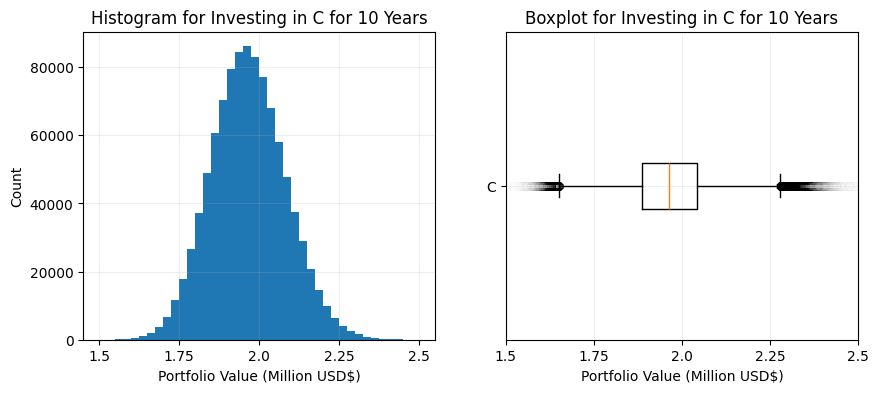

In [526]:
# fund C
print_stats(fund_C_values, "+ Fund C stats after 10 years:")



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_C_values, bins=range(1500000, 2500001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1500000,2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1500000, 2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax2.set_yticks([1], ["C"])
ax2.set_xlim(1500000,2500001)

plt.show()

+ Fund D stats after 10 years:
Mean: $1,790,826.00
Mean return: 79.08%
Standard Deviation: $30,803.29

Median: $1,790,566.34
Median return: 79.06%
Min: $1,662,953.40
Max: $1,930,784.21
Q1 (25th percentile): $1,769,676.23
Q3 (75th percentile): $1,811,759.05
IQR: $42,082.81

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.52%

Risk-averse score: 1.79036
Risk-neutral score: 1.79082
Risk-seeking score: 1.79128



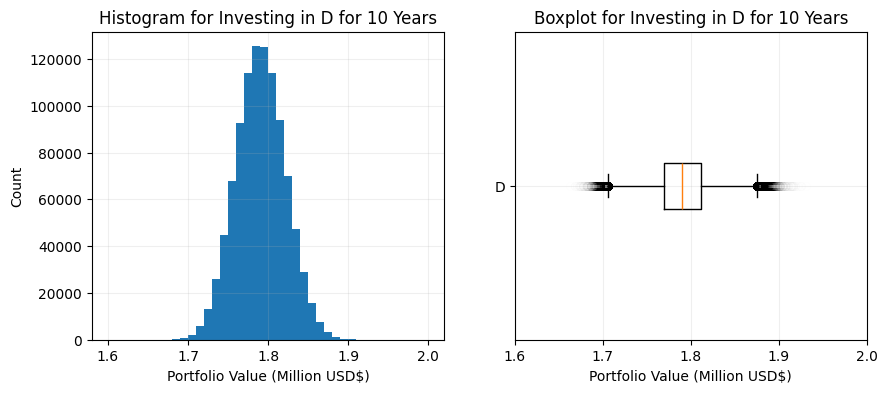

In [527]:
# fund D
print_stats(fund_D_values, "+ Fund D stats after 10 years:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1600000, 2000001, 10000)) # each bin will be 10k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1600000, 2000001, 100000), list(np.round(np.arange(1.6, 2.01, 0.1), 3))) # type: ignore
ax1.set_ylabel("Count")
	
box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1600000, 2000001, 100000), list(np.round(np.arange(1.6, 2.01, 0.1), 3))) # type: ignore
ax2.set_yticks([1], ["D"])
ax2.set_xlim(1600000,2000001)

plt.show()

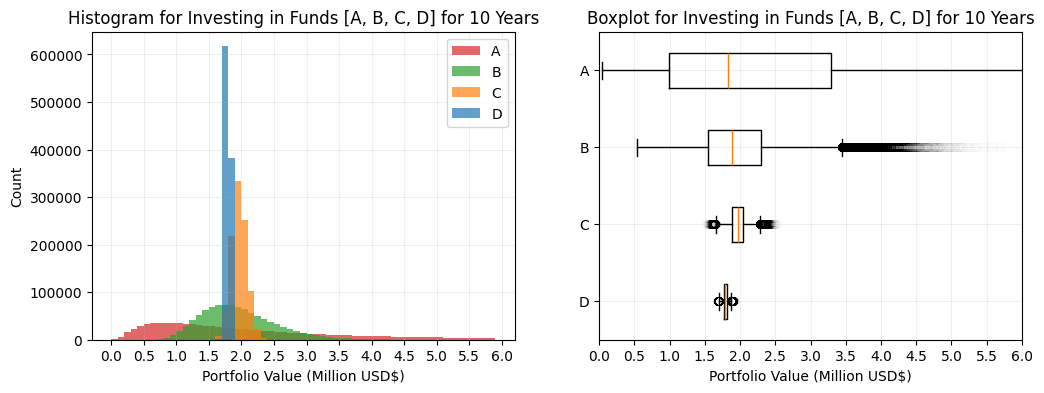

In [528]:
# combining the new outcomes for funds A, B, C, D into into a single plot for simplicity

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

stacked_hist = ax1.hist([fund_D_values, fund_C_values, fund_B_values, fund_A_values], histtype="stepfilled", bins=range(0, 6000000, 100000), label=["D", "C", "B", "A"], alpha=0.7)
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in Funds [A, B, C, D] for 10 Years")
ax1.legend()
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 6000001, 500000), labels=list(np.arange(0, 6.01, 0.5)))
ax1.set_ylabel("Count")

multi_boxplot = ax2.boxplot([fund_D_values, fund_C_values, fund_B_values, fund_A_values], label=["D", "C", "B", "A"], vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in Funds [A, B, C, D] for 10 Years")
ax2.set_xticks(range(0, 6000001, 500000), labels=list(np.arange(0, 6.01, 0.5)))
ax2.set_yticks(ticks=[1,2,3,4], labels=["D", "C", "B", "A"])
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(0, 6000001)

plt.show()

### Question 4:

##### Will it be a better strategy if we invest `$500,000` in fund A and `$500,000` in fund D? 

First, let's start with simulating 3 years:

In [529]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,260,819.93
Mean return: 26.08%
Standard Deviation: $312,919.35

Median: $1,202,261.70
Median return: 20.23%
Min: $696,058.69
Max: $2,623,188.76
Q1 (25th percentile): $1,024,507.30
Q3 (75th percentile): $1,437,603.48
IQR: $413,096.18

Percentage of failed portfolios: 21.57%
Percentage of outliers: 2.02%

Risk-averse score: 1.21613
Risk-neutral score: 1.25989
Risk-seeking score: 1.31166



Graphs for 3 year simulation:

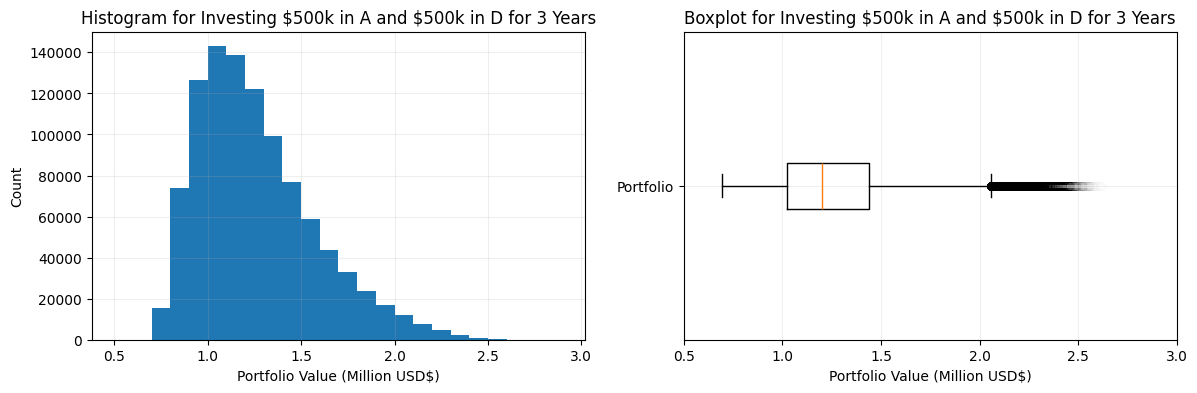

In [530]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(500000, 3000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(500000, 3000001)

plt.show()

Now let's simulate for 10 years:

In [531]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,192,136.10
Mean return: 119.21%
Standard Deviation: $1,261,877.78

Median: $1,806,941.85
Median return: 80.69%
Min: $888,928.31
Max: $25,241,721.52
Q1 (25th percentile): $1,393,638.84
Q3 (75th percentile): $2,541,716.57
IQR: $1,148,077.73

Percentage of failed portfolios: 0.86%
Percentage of outliers: 6.27%

Risk-averse score: 1.79730
Risk-neutral score: 2.17364
Risk-seeking score: 3.56186



Graphs for 10 year simulation:

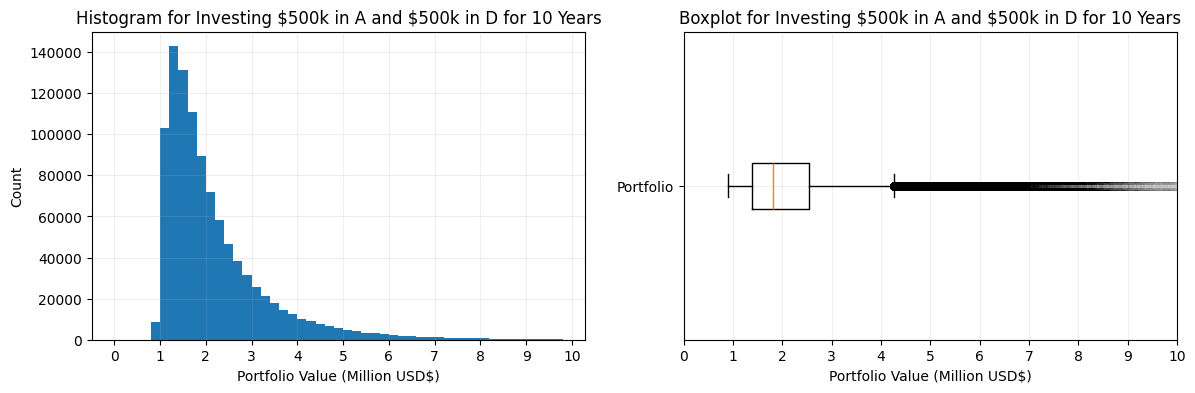

In [532]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(range(0, 11))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0,10000001, 1000000), list(range(0, 11))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(0, 10000000)

plt.show()

##### Or how about `$600,000` in fund B and `$400,000` in fund C?

We again start by simulating 3 years:

In [533]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,224,999.28
Mean return: 22.50%
Standard Deviation: $118,367.87

Median: $1,217,298.19
Median return: 21.73%
Min: $900,673.41
Max: $1,656,328.22
Q1 (25th percentile): $1,138,183.22
Q3 (75th percentile): $1,303,527.11
IQR: $165,343.89

Percentage of failed portfolios: 1.43%
Percentage of outliers: 0.36%

Risk-averse score: 1.21810
Risk-neutral score: 1.22488
Risk-seeking score: 1.23182



Graphs for 3 year simulation:

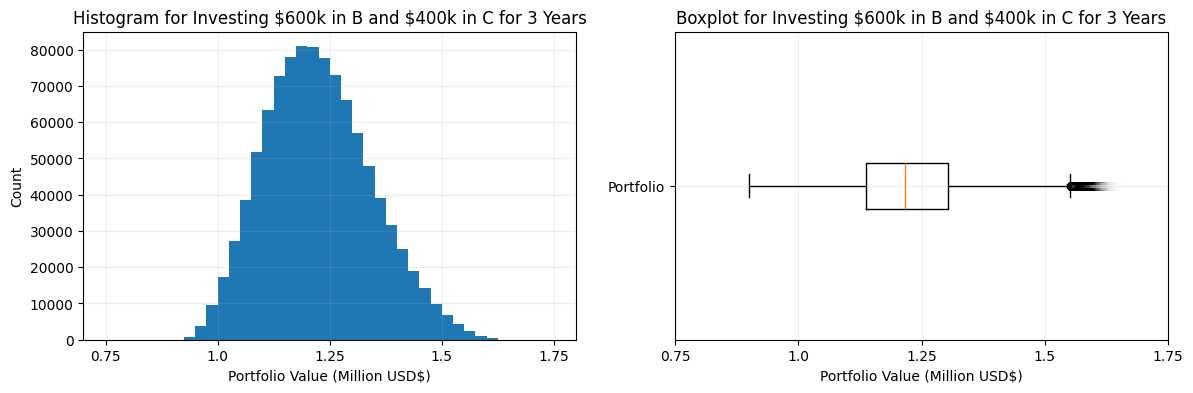

In [534]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 1750001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(750000, 1750001)

plt.show()

Now to simulate for 10 years:

In [535]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,967,431.99
Mean return: 96.74%
Standard Deviation: $352,127.59

Median: $1,921,020.28
Median return: 92.10%
Min: $1,078,084.41
Max: $4,478,079.30
Q1 (25th percentile): $1,713,756.74
Q3 (75th percentile): $2,171,812.29
IQR: $458,055.55

Percentage of failed portfolios: 0.00%
Percentage of outliers: 1.79%

Risk-averse score: 1.91104
Risk-neutral score: 1.96594
Risk-seeking score: 2.02959



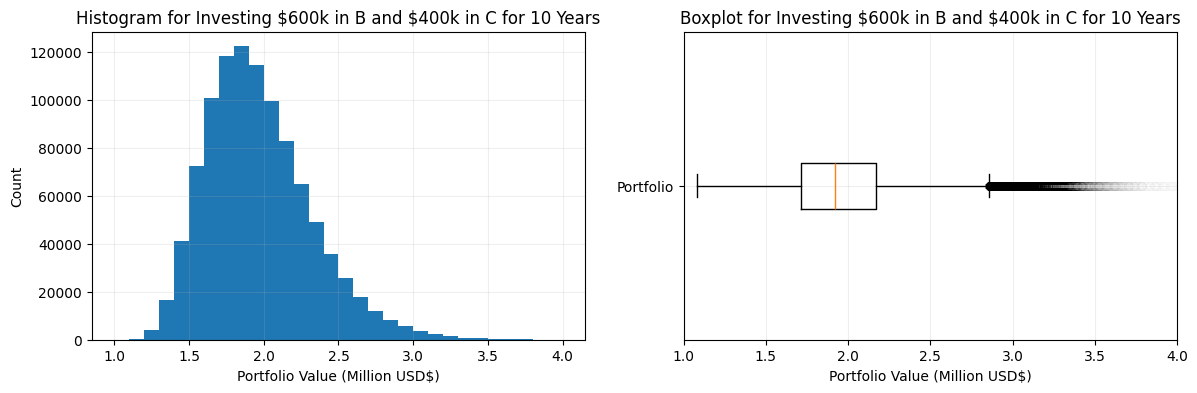

In [536]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(1000000, 4000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(1000000, 4000001)
plt.show()

##### Or how about `$800,000` in fund A and `$200,000` in fund C?

We again start by simulating 3 years:

In [537]:
portfolios = setup_portfolios([800000.0, 0.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,310,216.75
Mean return: 31.02%
Standard Deviation: $500,837.25

Median: $1,216,027.04
Median return: 21.60%
Min: $411,119.24
Max: $3,485,687.17
Q1 (25th percentile): $931,599.04
Q3 (75th percentile): $1,592,422.64
IQR: $660,823.60

Percentage of failed portfolios: 31.13%
Percentage of outliers: 2.04%

Risk-averse score: 1.20225
Risk-neutral score: 1.30877
Risk-seeking score: 1.44754



Graphs for 3 year simulation:

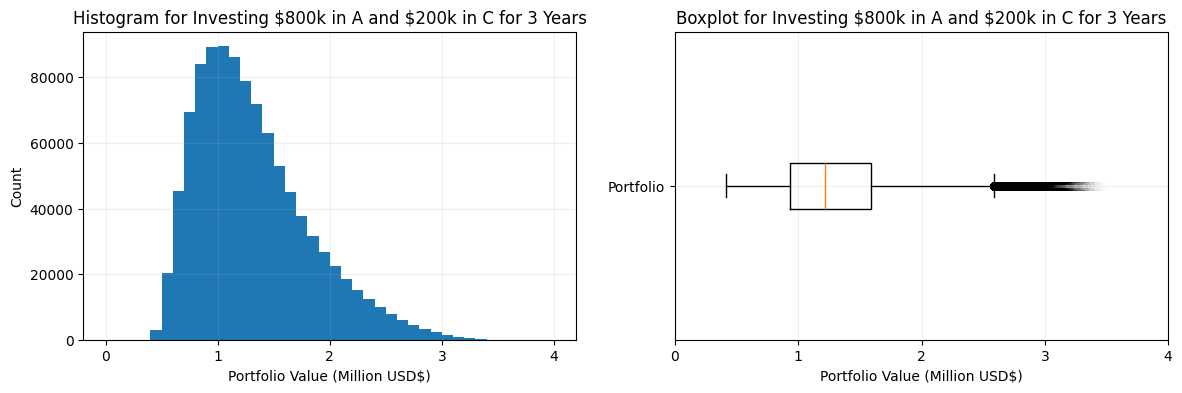

In [538]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 4000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$800k in A and \$200k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 5, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$800k in A and \$200k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 5, 1))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(0, 4000001)

plt.show()

Now to simulate for 10 years:

In [539]:
portfolios = setup_portfolios([800000.0, 0.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,464,221.15
Mean return: 146.42%
Standard Deviation: $2,011,238.34

Median: $1,851,937.78
Median return: 85.19%
Min: $367,335.46
Max: $40,785,974.77
Q1 (25th percentile): $1,189,464.14
Q3 (75th percentile): $3,020,704.50
IQR: $1,831,240.36

Percentage of failed portfolios: 16.46%
Percentage of outliers: 6.26%

Risk-averse score: 1.66509
Risk-neutral score: 2.43467
Risk-seeking score: 6.19417



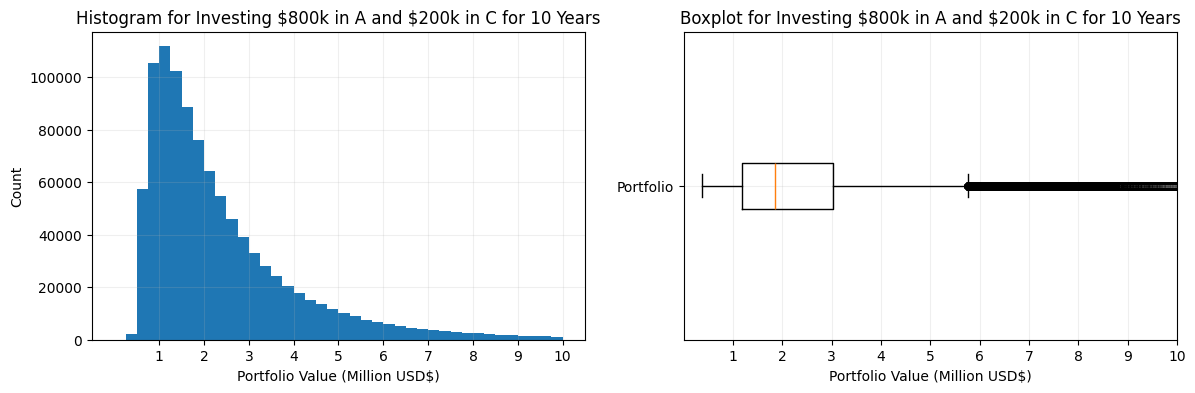

In [540]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 10000001, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$800k in A and \$200k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 10000001, 1000000), list(np.arange(1, 11, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$800k in A and \$200k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 10000001, 1000000), list(np.arange(1, 11, 1))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(0, 10000001)
plt.show()

##### Will it be a better strategy if we invest `$500,000` in fund A, `$300,000` in fund B and `$200,000` in fund C?

We start with simulating for 3 years:

In [541]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,278,466.37
Mean return: 27.85%
Standard Deviation: $319,055.78

Median: $1,220,872.10
Median return: 22.09%
Min: $597,901.58
Max: $2,736,149.94
Q1 (25th percentile): $1,040,239.78
Q3 (75th percentile): $1,459,539.81
IQR: $419,300.03

Percentage of failed portfolios: 19.57%
Percentage of outliers: 1.98%

Risk-averse score: 1.23210
Risk-neutral score: 1.27765
Risk-seeking score: 1.33135



Graphs for 3 years:

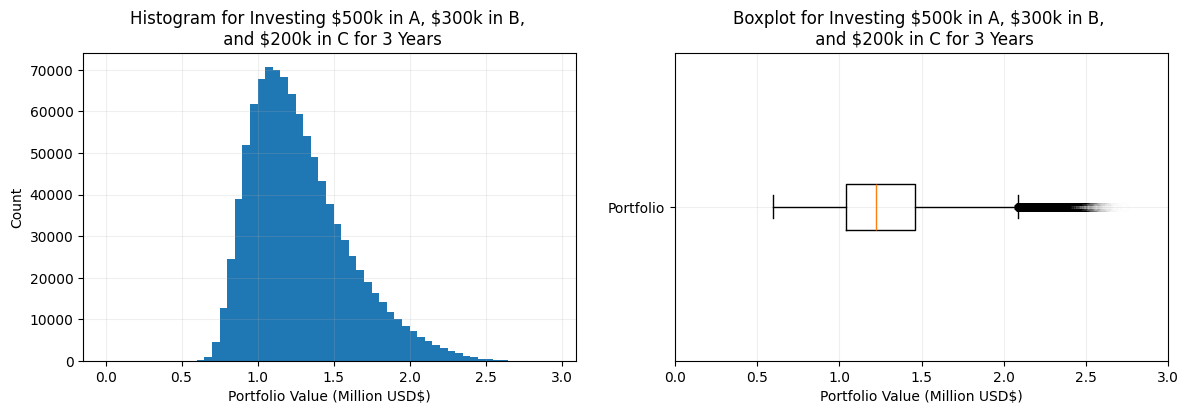

In [542]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 3000000, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 3000001, 500000), list(np.arange(0, 3.1, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 3000001, 500000), list(np.arange(0, 3.1, 0.5))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(0, 3000001)
plt.show()

Now we simulate for 10 years:

In [543]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,281,398.89
Mean return: 128.14%
Standard Deviation: $1,273,462.25

Median: $1,912,613.80
Median return: 91.26%
Min: $670,867.57
Max: $27,069,120.07
Q1 (25th percentile): $1,481,663.98
Q3 (75th percentile): $2,648,398.22
IQR: $1,166,734.24

Percentage of failed portfolios: 1.63%
Percentage of outliers: 6.14%

Risk-averse score: 1.87231
Risk-neutral score: 2.26321
Risk-seeking score: 3.65504



Graphs for 10 year simulation:

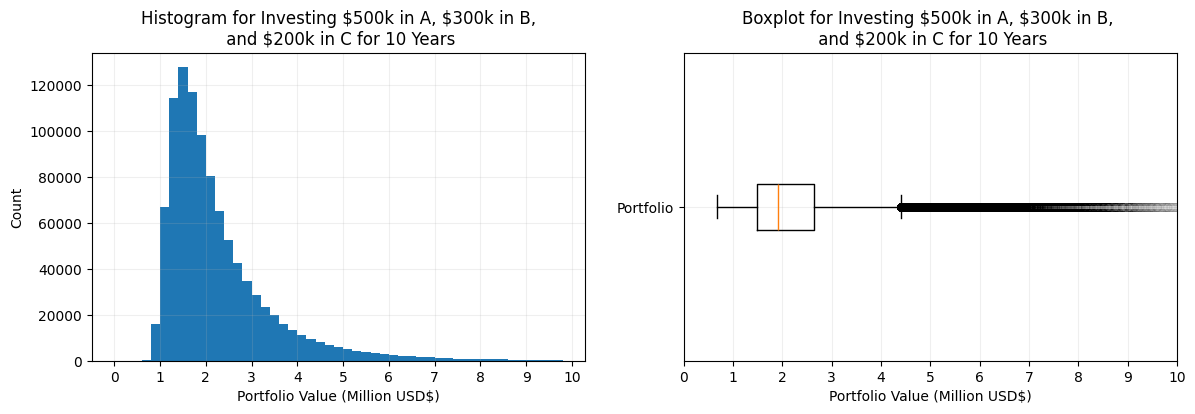

In [544]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B," + "\n " \
r"and \$200k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 11, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(0, 10000000)
ax2.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 11, 1))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])

plt.show()

##### How about investing `$100,000` in A, `$200,000` in B, and `$700,000` in C?

We start with simulating for 3 years:

In [545]:
portfolios = setup_portfolios([100000.0, 200000.0, 700000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,235,595.38
Mean return: 23.56%
Standard Deviation: $78,835.24

Median: $1,228,333.45
Median return: 22.83%
Min: $975,627.00
Max: $1,615,639.93
Q1 (25th percentile): $1,179,284.47
Q3 (75th percentile): $1,284,271.53
IQR: $104,987.06

Percentage of failed portfolios: 0.00%
Percentage of outliers: 1.14%

Risk-averse score: 1.23248
Risk-neutral score: 1.23545
Risk-seeking score: 1.23849



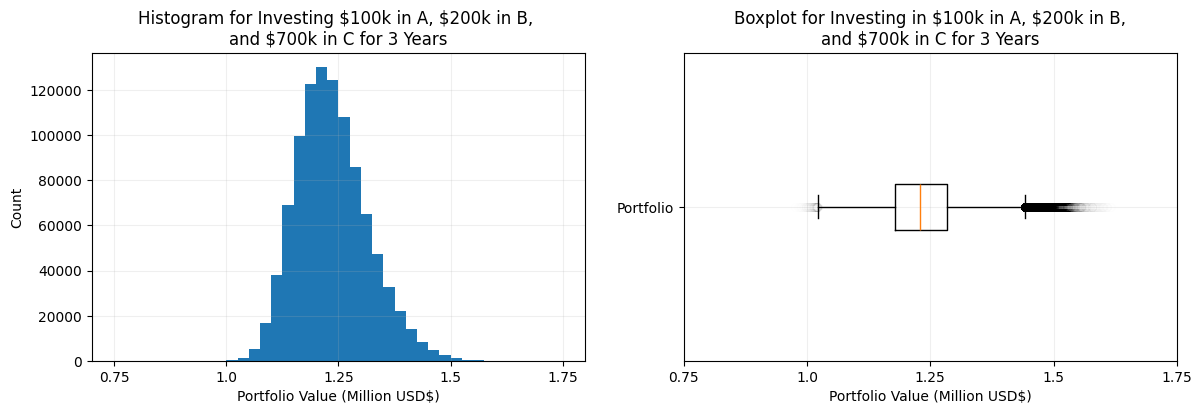

In [546]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 1750001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$100k in A, \$200k in B, " + "\n" \
r"and \$700k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 1750001, 250000), list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$100k in A, \$200k in B," + "\n" \
r"and \$700k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 1750001, 250000), list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(750000, 1750001)

plt.show()

Now we simulate for 10 years.

In [547]:
portfolios = setup_portfolios([100000.0, 200000.0, 700000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,030,058.33
Mean return: 103.01%
Standard Deviation: $289,328.10

Median: $1,975,500.52
Median return: 97.55%
Min: $1,328,844.43
Max: $6,801,752.51
Q1 (25th percentile): $1,841,266.19
Q3 (75th percentile): $2,150,156.01
IQR: $308,889.82

Percentage of failed portfolios: 0.00%
Percentage of outliers: 4.07%

Risk-averse score: 1.99403
Risk-neutral score: 2.02677
Risk-seeking score: 2.06792



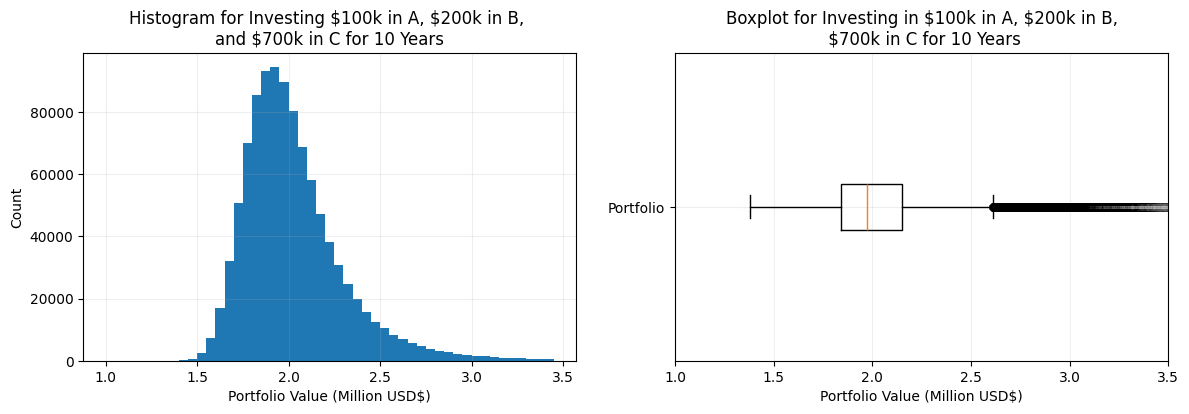

In [548]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(1000000, 3500000, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$100k in A, \$200k in B, " + "\n" \
r"and \$700k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 3500001, 500000), list(np.arange(1, 3.51, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$100k in A, \$200k in B," + "\n" \
r" \$700k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 3500001, 500000), list(np.arange(1, 3.51, 0.5))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(1000000, 3500001)

plt.show()

##### How about investing `$150,000` in A, `$750,000` in B, and `$100,000` in C?

We start with simulating for 3 years:

In [549]:
portfolios = setup_portfolios([150000.0, 750000.0, 100000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,240,792.86
Mean return: 24.08%
Standard Deviation: $174,013.80

Median: $1,229,898.41
Median return: 22.99%
Min: $730,787.08
Max: $2,040,732.76
Q1 (25th percentile): $1,115,082.90
Q3 (75th percentile): $1,355,096.51
IQR: $240,013.61

Percentage of failed portfolios: 7.41%
Percentage of outliers: 0.59%

Risk-averse score: 1.22602
Risk-neutral score: 1.24048
Risk-seeking score: 1.25541



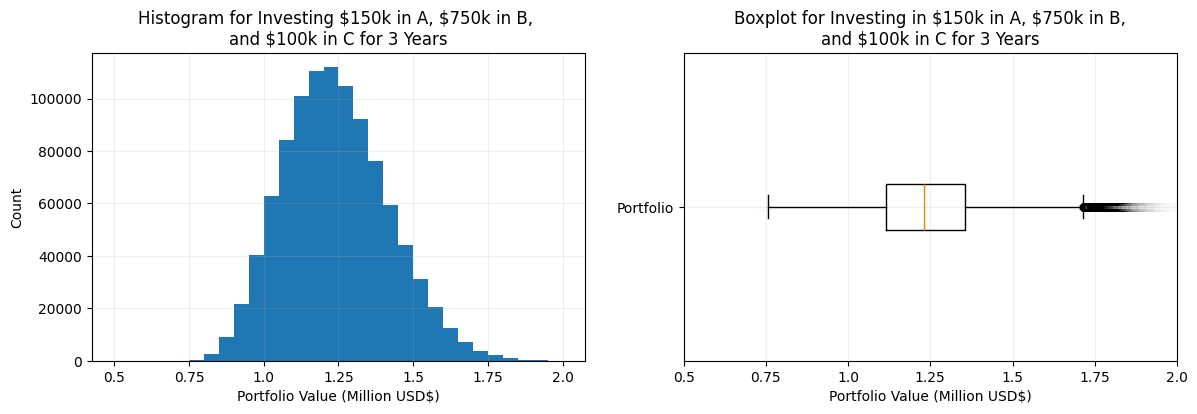

In [550]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(500000, 2000001, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$150k in A, \$750k in B, " + "\n" \
r"and \$100k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(500000, 2000001, 250000), list(np.arange(0.5, 2.01, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$150k in A, \$750k in B," + "\n" \
r"and \$100k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(500000, 2000001, 250000), list(np.arange(0.5, 2.01, 0.25))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(500000, 2000001)

plt.show()

Now we simulate for 10 years.

In [551]:
portfolios = setup_portfolios([150000.0, 750000.0, 100000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,060,898.33
Mean return: 106.09%
Standard Deviation: $577,016.30

Median: $1,973,659.41
Median return: 97.37%
Min: $712,834.98
Max: $11,207,951.83
Q1 (25th percentile): $1,653,828.63
Q3 (75th percentile): $2,368,021.30
IQR: $714,192.67

Percentage of failed portfolios: 0.28%
Percentage of outliers: 2.40%

Risk-averse score: 1.92363
Risk-neutral score: 2.05653
Risk-seeking score: 2.23520



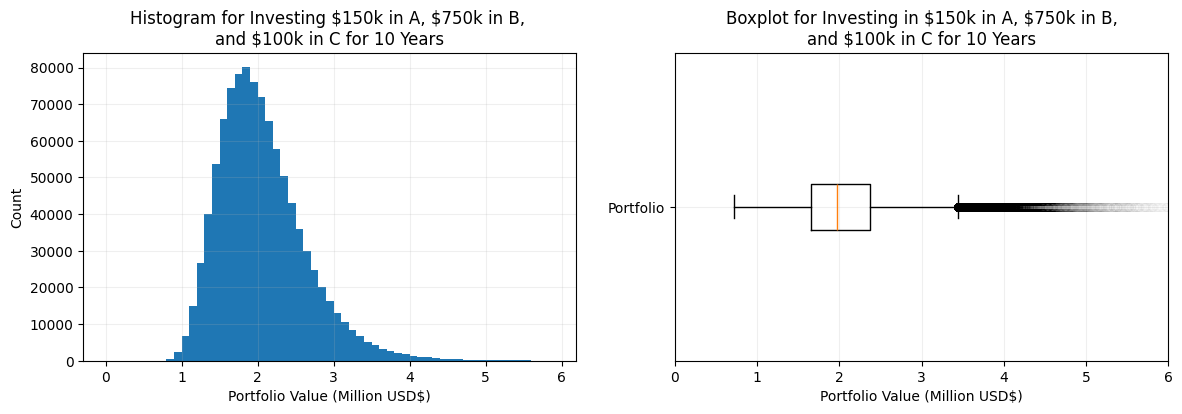

In [552]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 6000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$150k in A, \$750k in B, " + "\n" \
r"and \$100k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 6000001, 1000000), list(np.arange(0, 7, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$150k in A, \$750k in B," + "\n" \
r"and \$100k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 6000001, 1000000), list(np.arange(0, 7, 1))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(0, 6000001)

plt.show()

##### How about investing `$250,000` in each fund?

We start with simulating for 3 years:

In [553]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,242,715.95
Mean return: 24.27%
Standard Deviation: $164,252.40

Median: $1,216,172.64
Median return: 21.62%
Min: $858,188.75
Max: $2,033,974.52
Q1 (25th percentile): $1,121,640.50
Q3 (75th percentile): $1,337,318.00
IQR: $215,677.50

Percentage of failed portfolios: 2.87%
Percentage of outliers: 1.85%

Risk-averse score: 1.22971
Risk-neutral score: 1.24230
Risk-seeking score: 1.25592



Graphs for 3 years:

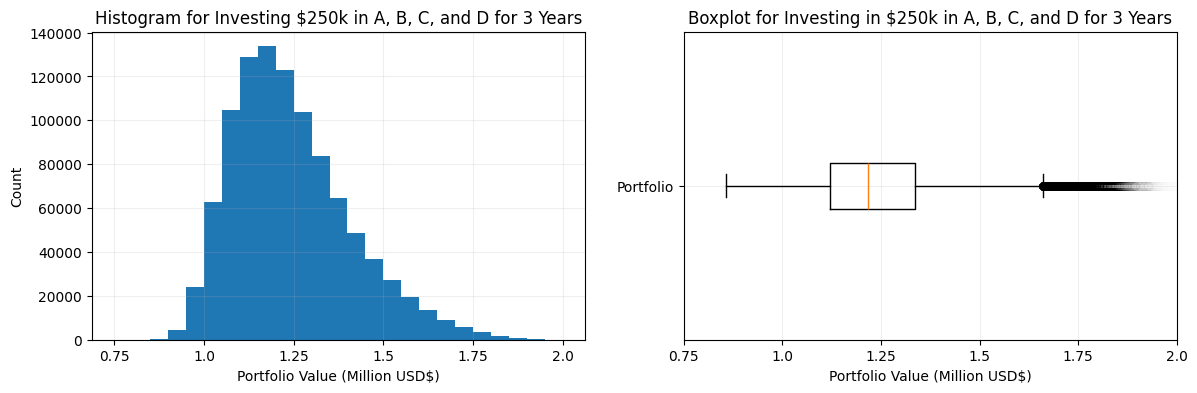

In [554]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 2000001, 50000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.001, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.01, 0.25))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])
ax2.set_xlim(750000, 2000001)

plt.show()

Now we simulate for 10 years:

In [555]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,080,111.79
Mean return: 108.01%
Standard Deviation: $648,020.23

Median: $1,906,567.57
Median return: 90.66%
Min: $1,100,810.16
Max: $16,019,607.10
Q1 (25th percentile): $1,671,696.35
Q3 (75th percentile): $2,279,361.25
IQR: $607,664.90

Percentage of failed portfolios: 0.00%
Percentage of outliers: 5.80%

Risk-averse score: 1.94088
Risk-neutral score: 2.07123
Risk-seeking score: 2.33316



Graphs for 10 years:

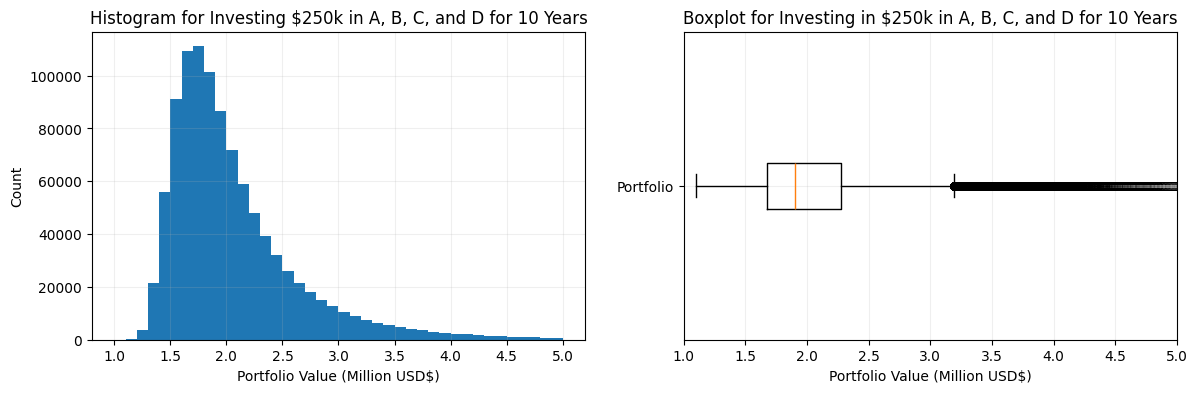

In [556]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(1000000, 5000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 5000001, 500000), list(np.arange(1, 5.01, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.002})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(1000000, 5000000)
ax2.set_xticks(range(1000000, 5000001, 500000), list(np.arange(1, 5.01, 0.5))) # type: ignore
ax2.set_yticks([1], ["Portfolio"])

plt.show()

### Question 5:

##### What is the best strategy you would recommend?

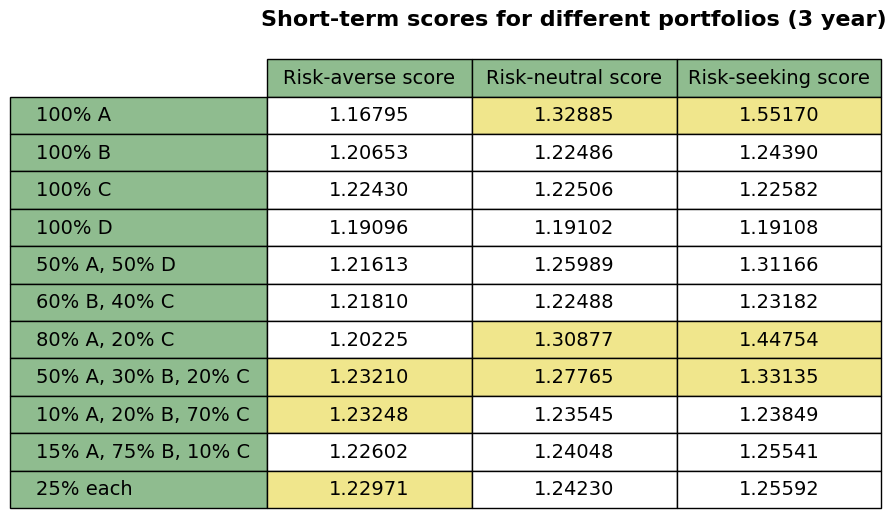

In [557]:
fig, ax = plt.subplots()
ax.axis('off')
ax.axis('tight')
ax.set_title("Short-term scores for different portfolios (3 year)", fontweight="bold", fontsize=16, pad=20)

#rounding for display 
cell_text = [[f"{val:.5f}" for val in row] for row in SHORT_TERM_SCORES]
table = ax.table(
    cellText=cell_text,
    rowLabels=["100% A", "100% B", "100% C", "100% D", "50% A, 50% D",
               "60% B, 40% C", "80% A, 20% C", "50% A, 30% B, 20% C",
               "10% A, 20% B, 70% C", "15% A, 75% B, 10% C", "25% each"],
    colLabels=["Risk-averse score", "Risk-neutral score", "Risk-seeking score"],
    cellLoc="center",
    loc="center",
    rowColours=["darkseagreen"] * len(SHORT_TERM_SCORES),
    colColours=["darkseagreen"] * 3
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.8)  # increase row height

# highlighting max score for each column
for i in range(3):
    col_values = [score[i] for score in SHORT_TERM_SCORES]
    max_3_values = sorted(col_values, reverse=True)[:3]
    for j, value in enumerate(col_values):
        if value in max_3_values:  # give some tolerance for max contender
            table[j + 1, i].set_facecolor("khaki")

# remove extra margins so table fills the axes (no gap at the top)
fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)

plt.show()

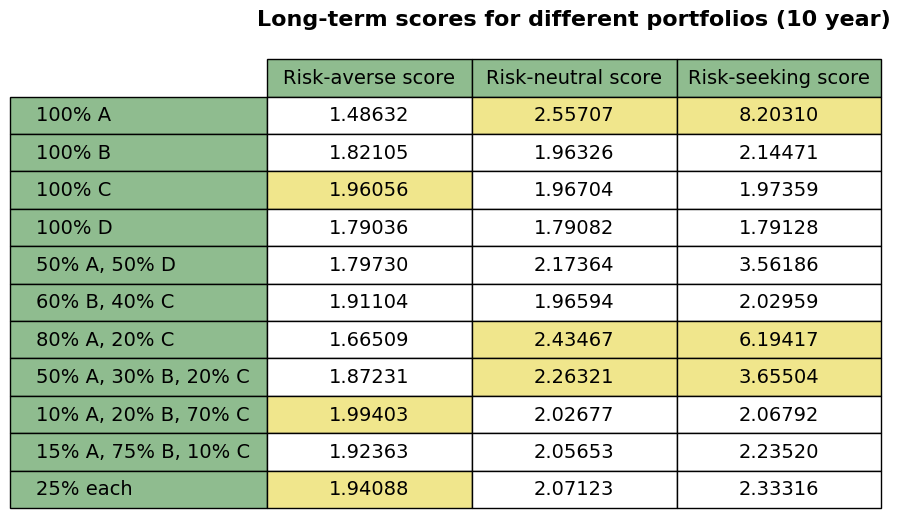

In [558]:
fig, ax = plt.subplots()
ax.axis('off')
ax.axis('tight')
ax.set_title("Long-term scores for different portfolios (10 year)", fontweight="bold", fontsize=16, pad=20)

#rounding for display 
cell_text = [[f"{val:.5f}" for val in row] for row in LONG_TERM_SCORES]

table = ax.table(
    cellText=cell_text,
    rowLabels=["100% A", "100% B", "100% C", "100% D", "50% A, 50% D",
               "60% B, 40% C", "80% A, 20% C", "50% A, 30% B, 20% C",
               "10% A, 20% B, 70% C", "15% A, 75% B, 10% C", "25% each"],
    colLabels=["Risk-averse score", "Risk-neutral score", "Risk-seeking score"],
    cellLoc="center",
    loc="center",
    rowColours=["darkseagreen"] * len(LONG_TERM_SCORES),
    colColours=["darkseagreen"] * 3
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.8)  # increase row height

# highlighting max score for each column
for i in range(3):
    col_values = [score[i] for score in LONG_TERM_SCORES]
    max_3_values = sorted(col_values, reverse=True)[:3]
    for j, value in enumerate(col_values):
        if value in max_3_values:
            table[j + 1, i].set_facecolor("khaki")

# remove extra margins so table fills the axes (no gap at the top)
fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)

plt.show()

Based on the scores, risk-averse investors should focus their money on stock C for long-term investing; diversification is a good way to reduce risk also. Risk-neutral investors should put a lot of their stocks in A, since the potential return is quite high. Risk-seeking investors are heavily incentivized to put the majority of their stocks in A for the same reason.

Rankings did not shift much when changing from 3 years to 10 years. Risk increased, so the risk-averse investor favored C more long-term, while the risk-neutral and risk-seeking investors favored A more. In general, diversification tends to do better than focusing on individual stocks.

D seems to be the least favorable stock to invest in. Although it is very stable, the return rate is too low to justify investing it over C.